# Center @ 0.20D and corners @ 0.10D by source

This notebook visualizes the held-out test predictions from the recommended `best_center_f1` evaluation across **BUU AP, Lumos AP, Mendeley PA, MICCAI-2019, and NIH ChestX-ray14**. It defaults to the post-processed `spine_chain` output and deterministically selects one stronger and one more challenging image from every source.

For each ground-truth vertebra, $D$ is the diagonal of the axis-aligned box enclosing its four TL/TR/BL/BR landmarks. The blue circle is the **0.20D center-matching gate**. Each purple circle is a **0.10D corner gate**. Matched predicted corners are reconstructed exactly from the evaluator's saved signed residuals. Green predicted corners pass 0.10D; red predicted corners fail it.

> The evaluation CSV does not store the direction of the center residual or the coordinates of unmatched false positives. Therefore, center matching is shown as its exact gate plus the evaluator's exact pass/fail and normalized-error label; false positives are reported in each title but are not placed on the image. This is a model-quality visualization for screening-support research, not a diagnostic display.

In [40]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Polygon
import numpy as np
import pandas as pd
from PIL import Image


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'src').is_dir() and (candidate / 'dataset' / 'processed').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the Spine-Opportunistic-Screening project root.')


PROJECT_ROOT = find_project_root(Path.cwd())
TEST_ROOT = PROJECT_ROOT / 'dataset' / 'processed' / 'test'
COCO_PATH = TEST_ROOT / '_annotations.keypoints.coco.json'
EVALUATION_ROOT = PROJECT_ROOT / 'outputs' / 'evaluations' / '29 Aug 2026 Lumos added' / 'best_center_f1'
PER_IMAGE_PATH = EVALUATION_ROOT / 'per_image_metrics.csv'
PER_INSTANCE_PATH = EVALUATION_ROOT / 'per_instance_metrics.csv'

MODEL_OUTPUT = 'spine_chain'  # Change to 'raw' to inspect unfiltered detections.
SAMPLES_PER_SOURCE = 2       # Two gives one strong and one challenging case per source.
CENTER_GATE = 0.15
CORNER_GATE = 0.10
CORNER_NAMES = ('tl', 'tr', 'bl', 'br')
SOURCE_ORDER = ('BUU AP', 'Lumos AP', 'Mendeley PA', 'MICCAI-2019', 'NIH ChestX-ray14')

print(f'Project: {PROJECT_ROOT}')
print(f'Evaluation: {EVALUATION_ROOT}')

Project: /Users/gcpuppy/Documents/AI/Spinal AI/Spine-Opportunistic-Screening
Evaluation: /Users/gcpuppy/Documents/AI/Spinal AI/Spine-Opportunistic-Screening/outputs/evaluations/29 Aug 2026 Lumos added/best_center_f1


In [41]:
required_paths = (COCO_PATH, PER_IMAGE_PATH, PER_INSTANCE_PATH)
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f'Missing required inputs: {missing_paths}')

with COCO_PATH.open('r', encoding='utf-8') as handle:
    coco = json.load(handle)

per_image = pd.read_csv(PER_IMAGE_PATH)
per_instance = pd.read_csv(PER_INSTANCE_PATH)
per_image = per_image.loc[per_image['model'].eq(MODEL_OUTPUT)].copy()
per_instance = per_instance.loc[per_instance['model'].eq(MODEL_OUTPUT)].copy()

required_image_columns = {
    'image', 'image_id', 'source_dataset', 'gt_count', 'tp_0.20d', 'fp_0.20d',
    'fn_0.20d', 'pck_0.10', 'usable_vertebra_recall', 'count_absolute_error',
}
required_instance_columns = {
    'image_id', 'status', 'gt_index', 'normalized_center_error',
    'center_matched_0.20d', 'all_corners_pck_0.10',
    *(f'{corner}_{axis}_px' for corner in CORNER_NAMES for axis in ('dx', 'dy')),
    *(f'{corner}_normalized_error' for corner in CORNER_NAMES),
}
assert required_image_columns <= set(per_image.columns), required_image_columns - set(per_image.columns)
assert required_instance_columns <= set(per_instance.columns), required_instance_columns - set(per_instance.columns)
assert set(SOURCE_ORDER) == set(per_image['source_dataset'].unique())

keypoint_aliases = {
    'top_left': 'tl', 'top_right': 'tr', 'bottom_left': 'bl', 'bottom_right': 'br',
    'tl': 'tl', 'tr': 'tr', 'bl': 'bl', 'br': 'br',
}
category_keypoints = tuple(
    keypoint_aliases.get(str(name).strip().lower(), str(name).strip().lower())
    for name in coco['categories'][0]['keypoints']
)
assert category_keypoints == CORNER_NAMES, f'Unexpected keypoint order: {category_keypoints}'

images_by_id = {int(image['id']): image for image in coco['images']}
annotations_by_image = {image_id: [] for image_id in images_by_id}
for annotation in coco['annotations']:
    annotations_by_image[int(annotation['image_id'])].append(annotation)


def annotation_corners(annotation: dict) -> np.ndarray:
    keypoints = np.asarray(annotation['keypoints'], dtype=float).reshape(-1, 3)
    if keypoints.shape != (4, 3) or not np.all(keypoints[:, 2] > 0):
        raise ValueError(f"Annotation {annotation.get('id')} does not have four visible landmarks.")
    return keypoints[:, :2]


def superior_to_inferior(annotation: dict) -> tuple[float, float]:
    center = annotation_corners(annotation).mean(axis=0)
    return float(center[1]), float(center[0])


for image_id, annotations in annotations_by_image.items():
    annotations.sort(key=superior_to_inferior)

expected_test_counts = {
    'BUU AP': 40, 'Lumos AP': 16, 'Mendeley PA': 87,
    'MICCAI-2019': 48, 'NIH ChestX-ray14': 32,
}
observed_test_counts = per_image.groupby('source_dataset')['image_id'].nunique().to_dict()
assert observed_test_counts == expected_test_counts, observed_test_counts
assert len(per_image) == 223
assert int(per_image['gt_count'].sum()) == 3060
print('Validated 223 test images and 3,060 GT vertebrae across all five sources.')

Validated 223 test images and 3,060 GT vertebrae across all five sources.


## Deterministic cross-source sample

Within each source, the first selection has the highest simple display-quality score and the second has the lowest. The score combines usable-vertebra recall and PCK@0.10, with penalties for count error and false positives. This is only a reproducible way to show a range of behavior; it is not an additional evaluation metric.

In [42]:
def choose_source_examples(group: pd.DataFrame, count: int) -> pd.DataFrame:
    ranked = group.copy()
    ranked['_display_score'] = (
        ranked['usable_vertebra_recall'].fillna(0.0)
        + ranked['pck_0.10'].fillna(0.0)
        - 0.25 * ranked['count_absolute_error'].fillna(ranked['gt_count'])
        - 0.05 * ranked['fp_0.20d'].fillna(0.0)
    )
    ranked = ranked.sort_values(['_display_score', 'image_id'], ascending=[False, True])
    if count <= 1:
        return ranked.head(1).assign(example='stronger')

    positions = np.linspace(0, len(ranked) - 1, num=min(count, len(ranked)), dtype=int)
    selected = ranked.iloc[positions].copy()
    labels = ['stronger', *[f'range-{index}' for index in range(2, len(selected))], 'challenging']
    selected['example'] = labels[:len(selected)]
    return selected


sampled = pd.concat(
    [
        choose_source_examples(per_image.loc[per_image['source_dataset'].eq(source)], SAMPLES_PER_SOURCE)
        for source in SOURCE_ORDER
    ],
    ignore_index=True,
)
sampled['source_dataset'] = pd.Categorical(sampled['source_dataset'], SOURCE_ORDER, ordered=True)
sampled = sampled.sort_values(['source_dataset', '_display_score'], ascending=[True, False]).reset_index(drop=True)

display_columns = [
    'source_dataset', 'example', 'image_id', 'image', 'gt_count', 'tp_0.20d',
    'fp_0.20d', 'fn_0.20d', 'pck_0.10', 'usable_vertebra_recall',
]
sampled[display_columns].style.format({
    'pck_0.10': '{:.3f}', 'usable_vertebra_recall': '{:.3f}',
})

,source_dataset,example,image_id,image,gt_count,tp_0.20d,fp_0.20d,fn_0.20d,pck_0.10,usable_vertebra_recall
0,BUU AP,stronger,23,images/buu_ap/BUU-AP-00023.jpg,5,5,0,0,1.000,1.000
1,BUU AP,challenging,364,images/buu_ap/BUU-AP-00364.jpg,5,5,5,0,0.800,0.800
2,Lumos AP,stronger,1769,images/lumos_ap/lumos_AP_105.png,9,9,0,0,1.000,1.000
3,Lumos AP,challenging,1774,images/lumos_ap/lumos_AP_159.png,7,7,1,0,0.679,0.714
4,Mendeley PA,stronger,875,images/mendeley_pa/MENDE-PA-00549.jpg,17,17,0,0,1.000,1.000
5,Mendeley PA,challenging,487,images/mendeley_pa/MENDE-PA-00100.jpg,19,16,0,3,0.328,0.211
6,MICCAI-2019,stronger,1662,images/miccai_2019/MICCAI-AP-00390.jpg,17,17,0,0,1.000,1.000
7,MICCAI-2019,challenging,1368,images/miccai_2019/MICCAI-AP-00096.jpg,17,9,1,8,0.639,0.412
8,NIH ChestX-ray14,stronger,1764,images/nih_chestxray14/NIH_00030121_001.png,13,13,0,0,1.000,1.000
9,NIH ChestX-ray14,challenging,1753,images/nih_chestxray14/NIH_00006596_003.png,9,6,6,3,0.333,0.111


## Threshold overlays

- **Blue circle:** exact center gate, radius $0.20D$, around the GT center. `C✓`/`C✗` and the adjacent normalized error come directly from the evaluator.
- **Purple circles:** exact corner gates, radius $0.10D$, around GT TL/TR/BL/BR.
- **Cyan solid quadrilateral:** GT TL/TR/BR/BL outline.
- **Yellow dashed quadrilateral:** reconstructed matched prediction.
- **Green/red prediction points:** individual predicted corner passes/fails at 0.10D. Thin lines show signed GT-to-prediction residuals.
- **Red × at a GT center:** missed ground truth at the primary 0.20D center gate.

In [43]:
def as_bool(value) -> bool:
    if pd.isna(value):
        return False
    if isinstance(value, str):
        return value.strip().lower() == 'true'
    return bool(value)


def vertebral_diagonal(corners: np.ndarray) -> float:
    return max(float(np.linalg.norm(corners.max(axis=0) - corners.min(axis=0))), 1e-6)


def predicted_corners_from_residuals(gt_corners: np.ndarray, row: pd.Series) -> np.ndarray:
    residuals = np.asarray(
        [[row[f'{name}_dx_px'], row[f'{name}_dy_px']] for name in CORNER_NAMES],
        dtype=float,
    )
    if not np.isfinite(residuals).all():
        raise ValueError('A matched row is missing finite corner residuals.')
    return gt_corners + residuals


def instance_lookup(image_id: int) -> dict[int, pd.Series]:
    columns = [
        'status', 'gt_index', 'normalized_center_error', 'center_matched_0.20d',
        'all_corners_pck_0.10',
        *[f'{name}_{field}' for name in CORNER_NAMES
          for field in ('dx_px', 'dy_px', 'normalized_error')],
    ]
    mask = per_instance['image_id'].eq(image_id)
    rows = per_instance.loc[mask, columns].copy()
    rows = rows.loc[rows['status'].isin(['matched', 'missed_ground_truth'])]
    return {int(row['gt_index']): row for _, row in rows.iterrows()}


def plot_threshold_overlay(ax: plt.Axes, image_row: pd.Series) -> None:
    image_id = int(image_row['image_id'])
    image_path = TEST_ROOT / str(image_row['image'])
    if not image_path.is_file():
        raise FileNotFoundError(image_path)
    with Image.open(image_path) as handle:
        image = np.asarray(handle.convert('L'))

    annotations = annotations_by_image[image_id]
    rows_by_gt = instance_lookup(image_id)
    assert len(annotations) == int(image_row['gt_count'])
    assert set(rows_by_gt) == set(range(len(annotations)))

    ax.imshow(image, cmap='gray', vmin=np.percentile(image, 0.5), vmax=np.percentile(image, 99.5))
    center_passes = 0
    all_corner_passes = 0

    for gt_index, annotation in enumerate(annotations):
        gt = annotation_corners(annotation)
        gt_center = gt.mean(axis=0)
        diagonal = vertebral_diagonal(gt)
        row = rows_by_gt[gt_index]

        ax.add_patch(Circle(gt_center, CENTER_GATE * diagonal, fill=False,
                            edgecolor='#2f80ed', linewidth=0.8, alpha=0.55))
        for corner in gt:
            ax.add_patch(Circle(corner, CORNER_GATE * diagonal, fill=False,
                                edgecolor='#bb6bd9', linewidth=0.65, alpha=0.50))
        ax.add_patch(Polygon(gt[[0, 1, 3, 2]], closed=True, fill=False,
                             edgecolor='#56ccf2', linewidth=0.9, alpha=0.85))
        ax.scatter(gt[:, 0], gt[:, 1], s=8, c='#56ccf2', marker='o', linewidths=0, zorder=5)

        if row['status'] == 'matched':
            predicted = predicted_corners_from_residuals(gt, row)
            normalized_errors = np.asarray(
                [row[f'{name}_normalized_error'] for name in CORNER_NAMES], dtype=float
            )
            corner_pass = normalized_errors <= CORNER_GATE + 1e-7
            center_pass = as_bool(row['center_matched_0.20d'])
            all_corner_pass = as_bool(row['all_corners_pck_0.10'])
            center_passes += int(center_pass)
            all_corner_passes += int(all_corner_pass)

            ax.add_patch(Polygon(predicted[[0, 1, 3, 2]], closed=True, fill=False,
                                 edgecolor='#f2c94c', linestyle='--', linewidth=1.0, alpha=0.95))
            for corner_index, (gt_corner, pred_corner) in enumerate(zip(gt, predicted)):
                color = '#27ae60' if corner_pass[corner_index] else '#eb5757'
                ax.plot([gt_corner[0], pred_corner[0]], [gt_corner[1], pred_corner[1]],
                        color=color, linewidth=0.65, alpha=0.75, zorder=4)
                ax.scatter(*pred_corner, s=16, c=color, marker='o', edgecolors='black',
                           linewidths=0.25, zorder=6)
            normalized_center_error = float(row['normalized_center_error'])
            label = f"C{'✓' if center_pass else '✗'} {normalized_center_error:.2f}D | K {corner_pass.sum()}/4"
            label_color = '#27ae60' if center_pass and all_corner_pass else '#f2994a'
        else:
            ax.scatter(*gt_center, s=34, c='#eb5757', marker='x', linewidths=1.3, zorder=7)
            label = 'C✗ | missed'
            label_color = '#eb5757'

        ax.text(gt_center[0] + 0.23 * diagonal, gt_center[1], label, color='white', fontsize=5.5,
                ha='left', va='center', zorder=8,
                bbox={'facecolor': label_color, 'edgecolor': 'none', 'alpha': 0.78, 'pad': 1.0})

    source = str(image_row['source_dataset'])
    kind = str(image_row['example'])
    filename = Path(str(image_row['image'])).name
    ax.set_title(
        f'{source} · {kind}\n{filename}\n'
        f'center: {center_passes}/{len(annotations)} @0.20D · '
        f'all corners: {all_corner_passes}/{len(annotations)} @0.10D · '
        f"FP: {int(image_row['fp_0.20d'])}",
        fontsize=9,
    )
    ax.set_xlim(0, image.shape[1])
    ax.set_ylim(image.shape[0], 0)
    ax.axis('off')


legend_handles = [
    Line2D([0], [0], color='#2f80ed', lw=1.5, label='center gate: 0.20D'),
    Line2D([0], [0], color='#bb6bd9', lw=1.5, label='corner gate: 0.10D'),
    Line2D([0], [0], color='#56ccf2', lw=1.5, label='GT quadrilateral'),
    Line2D([0], [0], color='#f2c94c', lw=1.5, ls='--', label='matched prediction'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#27ae60',
           markeredgecolor='black', label='corner passes 0.10D'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#eb5757',
           markeredgecolor='black', label='corner fails 0.10D'),
    Line2D([0], [0], marker='x', color='#eb5757', lw=0, label='GT missed @0.20D'),
]

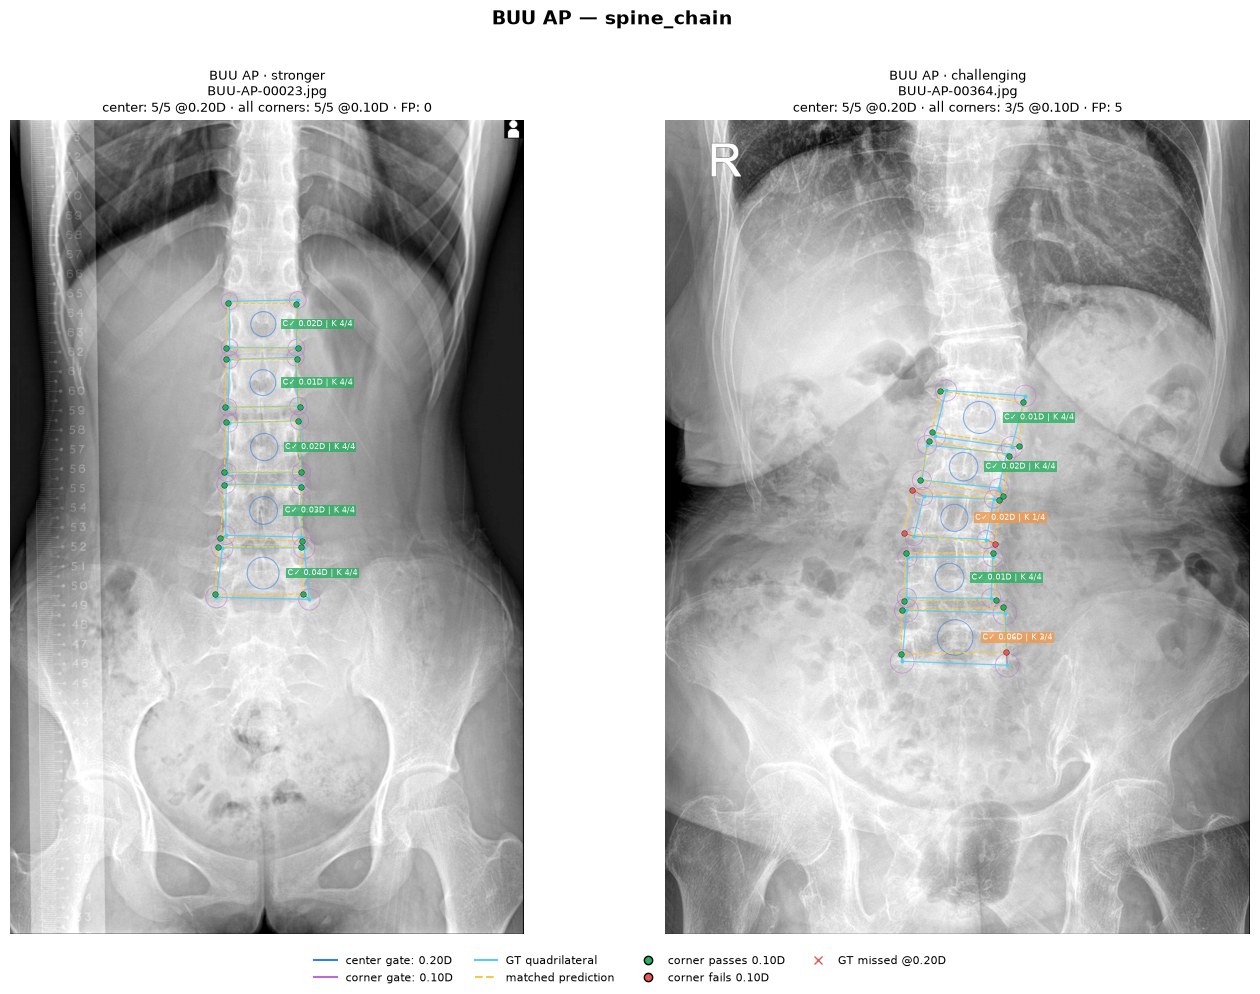

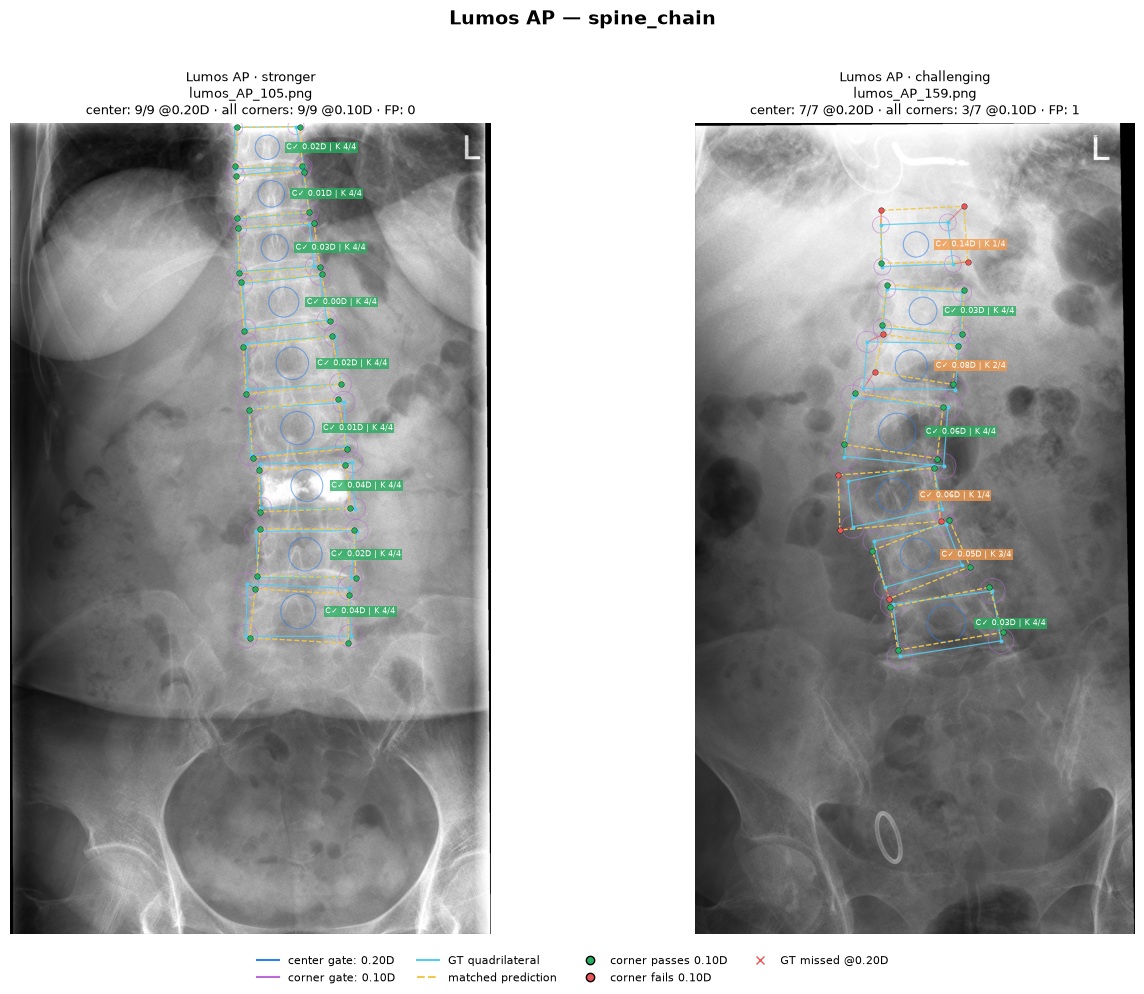

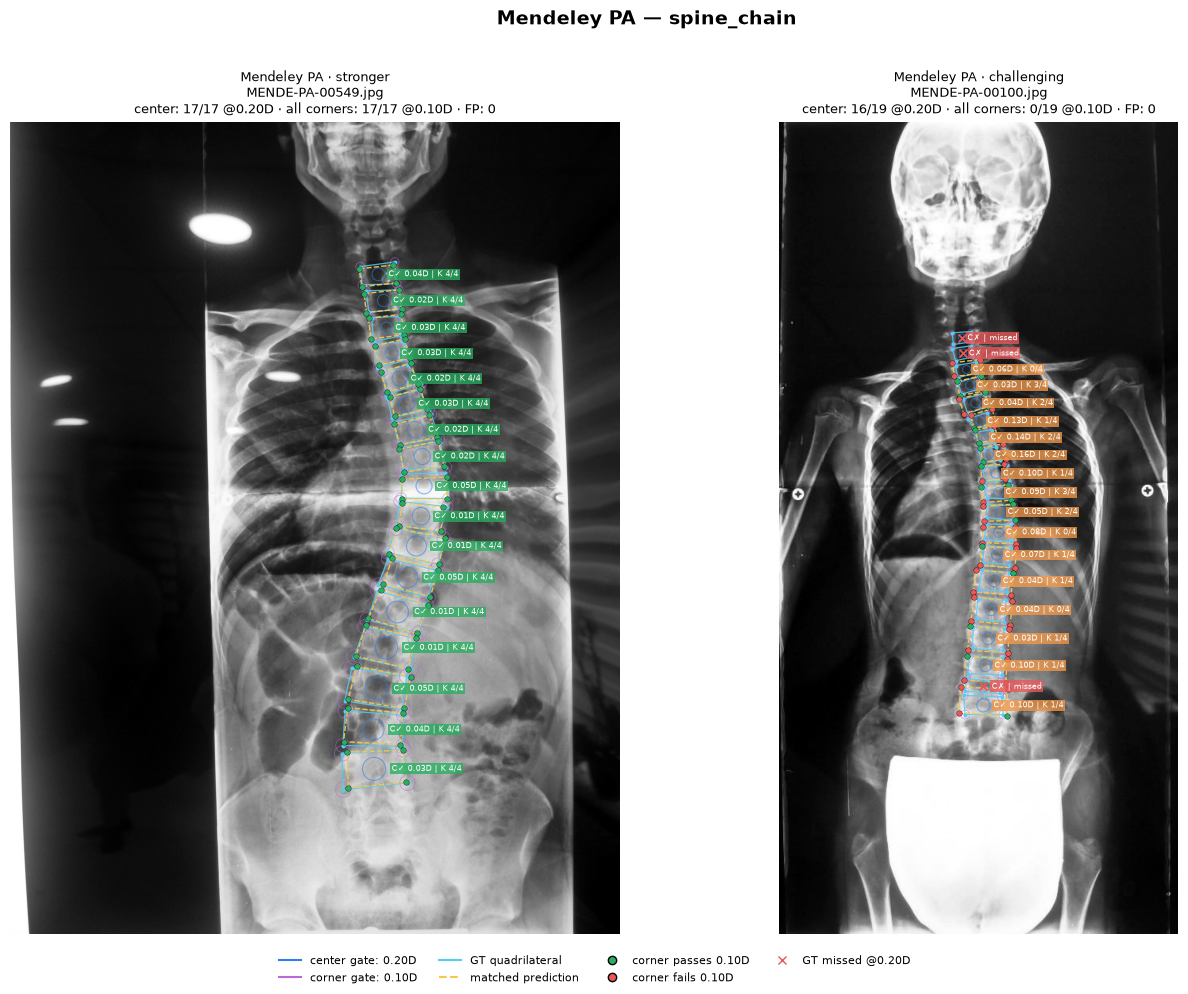

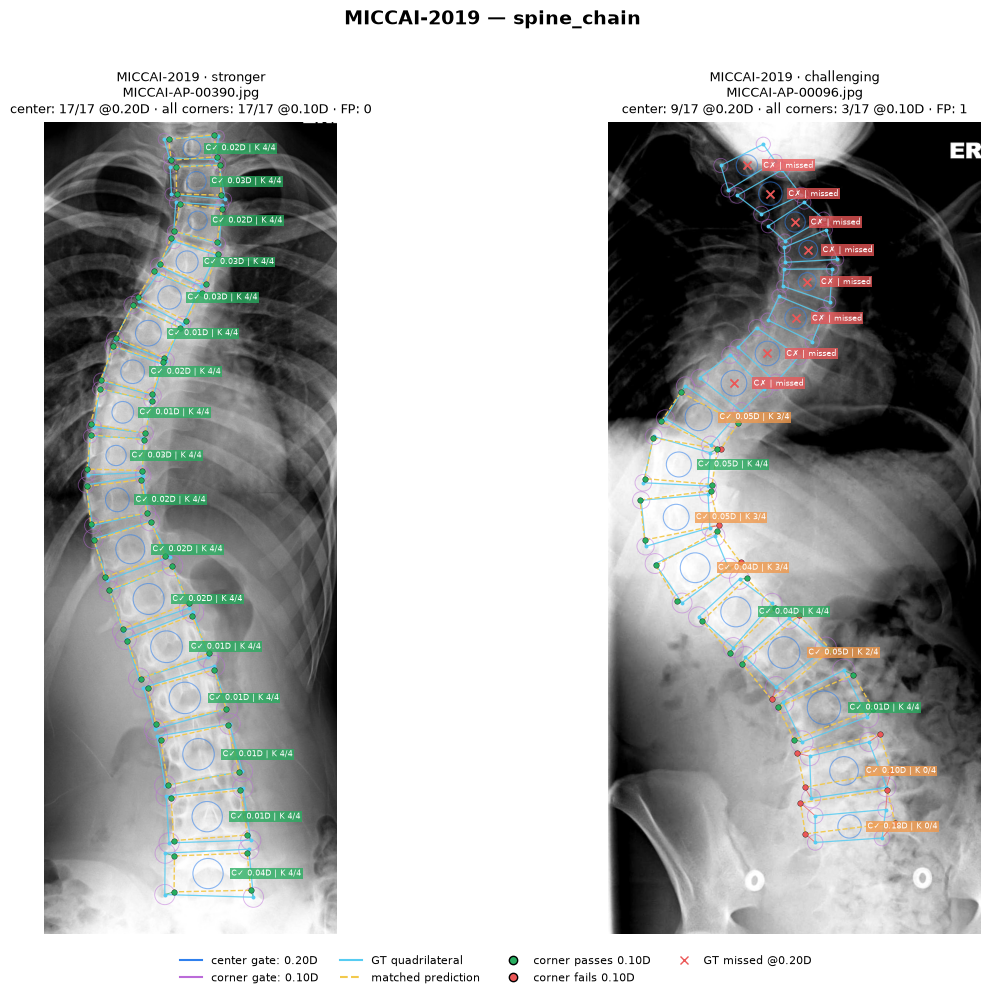

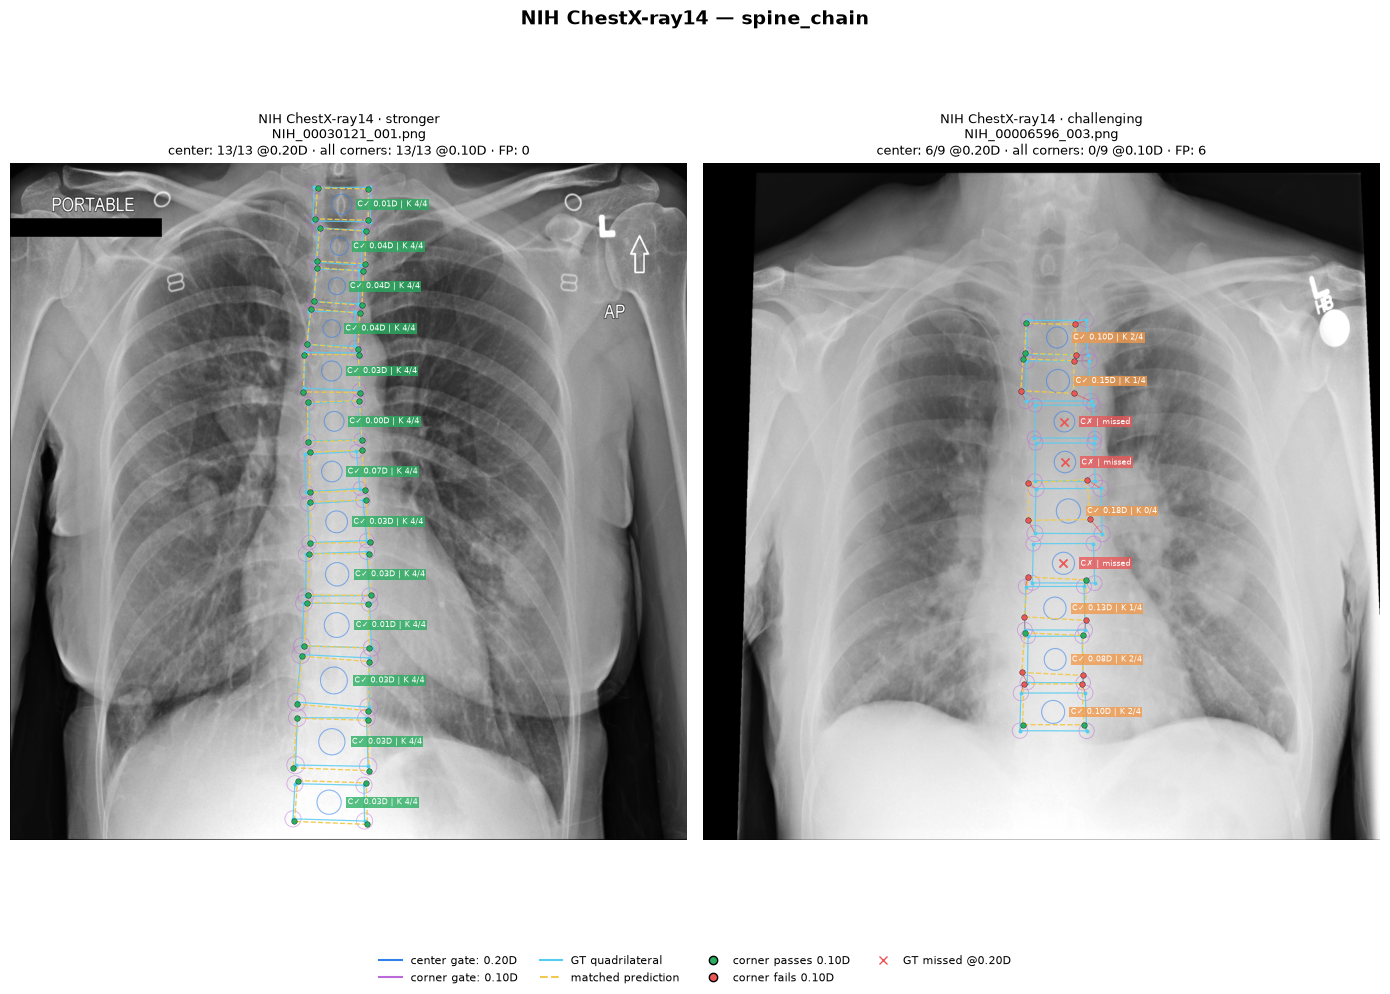

In [44]:
for source in SOURCE_ORDER:
    source_rows = sampled.loc[sampled['source_dataset'].eq(source)]
    figure, axes = plt.subplots(1, len(source_rows), figsize=(7 * len(source_rows), 10), squeeze=False)
    for axis, (_, image_row) in zip(axes[0], source_rows.iterrows()):
        plot_threshold_overlay(axis, image_row)
    figure.legend(handles=legend_handles, loc='lower center', ncol=4, frameon=False, fontsize=8)
    figure.suptitle(f'{source} — {MODEL_OUTPUT}', fontsize=14, fontweight='bold')
    figure.tight_layout(rect=(0, 0.04, 1, 0.97))
    plt.show()
    plt.close(figure)

## Inspect a specific test image

Set `IMAGE_ID` to any ID in the sample table or `per_image` dataframe. This keeps manual review on the exact same overlays and evaluator outputs.

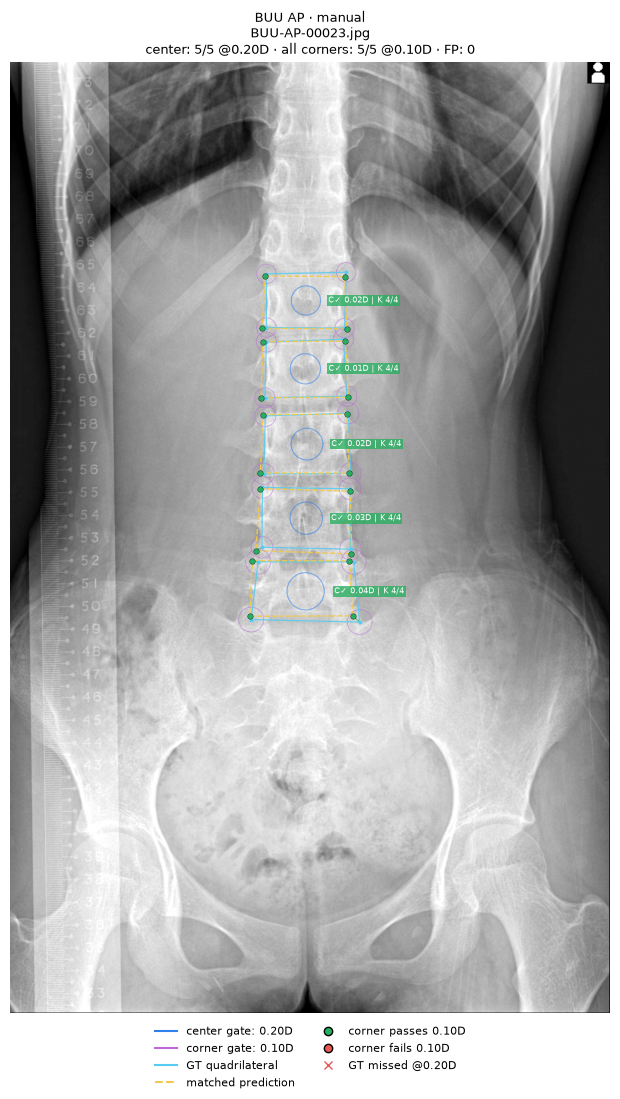

In [45]:
IMAGE_ID = int(sampled.iloc[0]['image_id'])
manual_rows = per_image.loc[per_image['image_id'].eq(IMAGE_ID)].copy()
if len(manual_rows) != 1:
    raise ValueError(f'Expected one {MODEL_OUTPUT!r} row for image_id={IMAGE_ID}, found {len(manual_rows)}.')
manual_rows['example'] = 'manual'

figure, axis = plt.subplots(figsize=(8, 11))
plot_threshold_overlay(axis, manual_rows.iloc[0])
figure.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False, fontsize=8)
figure.tight_layout(rect=(0, 0.06, 1, 1))
plt.show()
plt.close(figure)